 ## Teoría De Circuitos 2

## Trabajo Semanal Nº9
#### Facundo Sussini

In [29]:
from IPython.display import IFrame
IFrame("./Teoría de los Circuitos II - R4052_ Trabajo semanal 9 - Laboratorio de Filtros digitales _ Facultad Regional Buenos Aires.pdf", width=1000, height=1000)

[('ecg_lead', (1129116, 1), 'double'),
 ('qrs_pattern1', (113, 1), 'double'),
 ('heartbeat_pattern1', (411, 1), 'double'),
 ('heartbeat_pattern2', (441, 1), 'double'),
 ('qrs_detections', (1903, 1), 'double')]

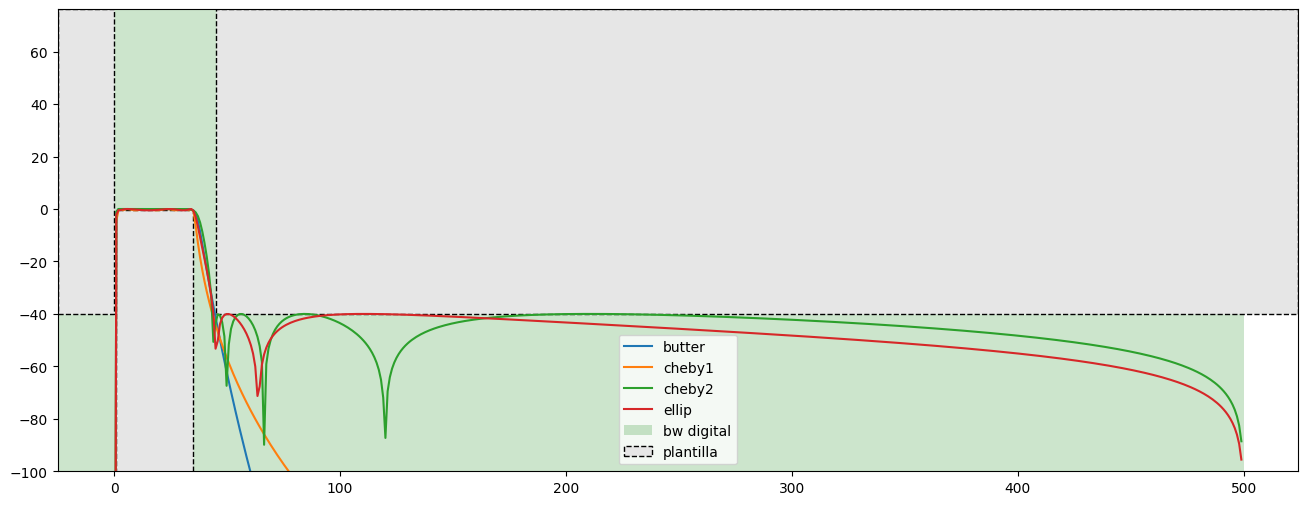

C:\Users\Usuario\AppData\Local\Temp\ipykernel_26092\3064902257.py:126: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


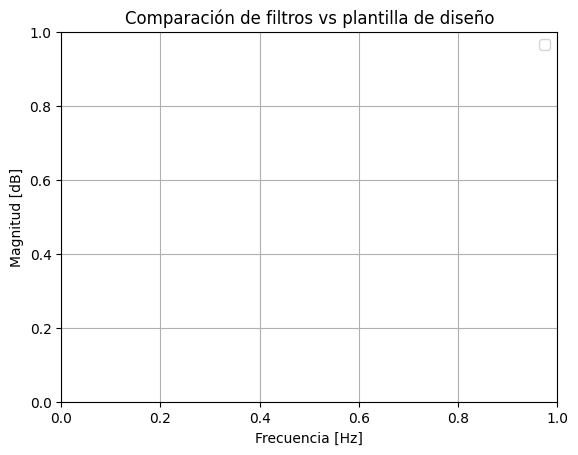

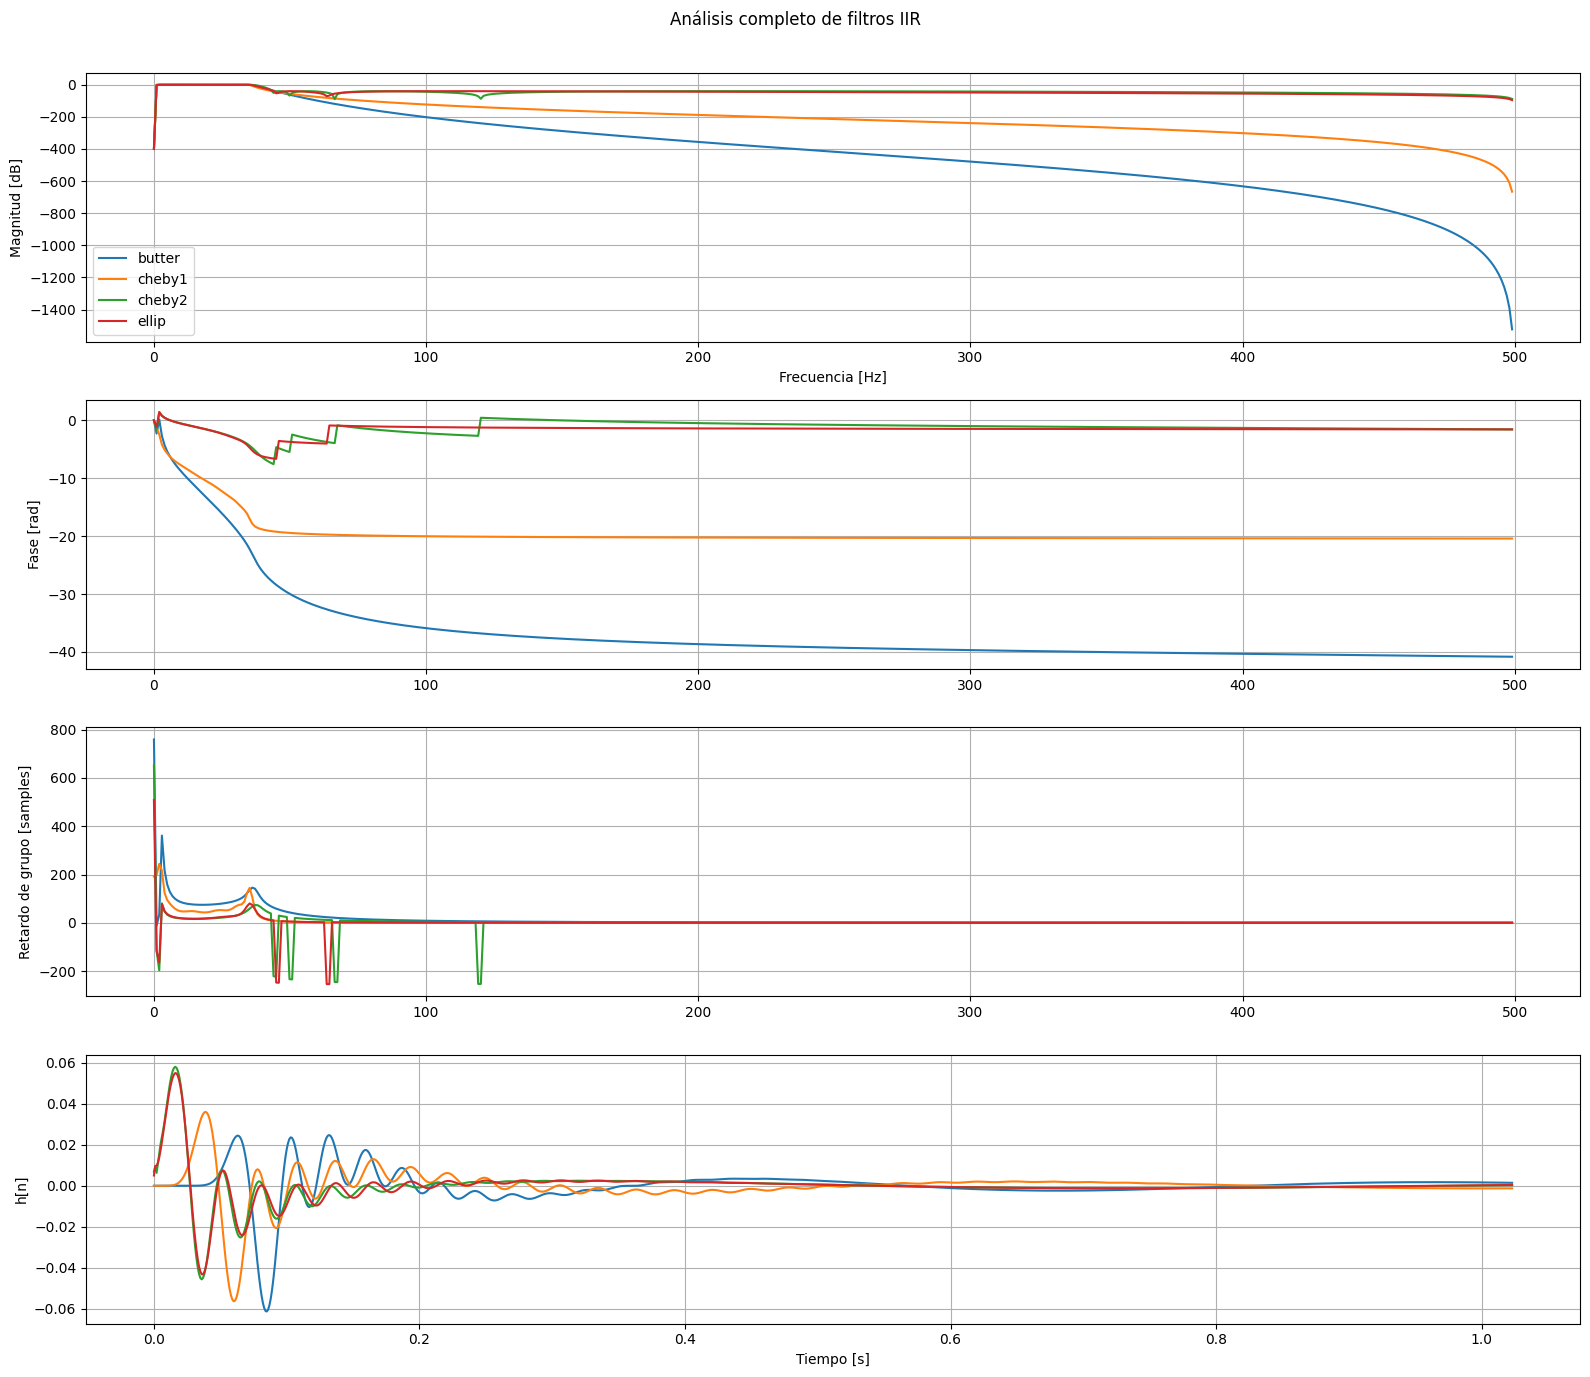

In [30]:
# Import common packages
from IPython.display import display, Markdown
import numpy as np
import scipy.signal as sig
import scipy.io as sio
from pytc2.sistemas_lineales import plot_plantilla
import matplotlib.pyplot as plt

# Carga del ECG
display(sio.whosmat("ecg.mat"))
mat_struct = sio.loadmat("ecg.mat")
ecg_one_lead = mat_struct["ecg_lead"].flatten()

# Parametros del filtro
ripple_db = 0.5  # Ripple en dB
atten_db = 40    # Atenuacion en dB

# Plantilla BandStop
fs1 = 0.1  # Hz
fp1 = 1    # Hz
fp2 = 35   # Hz
fs2 = 45   # Hz

# Parametros del sistema
fs = 1000  # Hz
nyq = fs / 2

#---------------------------------------------------------------------
def mag_phase_delay_impulseresp(
    b=None,
    a=None,
    sos=None,
    fs=2,
    worN=512,
    n_imp=1024,
    gd_units="samples",
    max_display_s=0.1,
):
    """
    Calcula magnitud, fase, retardo de grupo e impulso.
    Devuelve un diccionario con los resultados numéricos.
    """

    # --- frecuencia y respuesta en frecuencia
    if sos is not None:
        w, h = sig.sosfreqz(sos, worN=worN, fs=fs)
    else:
        w, h = sig.freqz(b, a, worN=worN, fs=fs)

    abs_h = np.abs(h)
    abs_h[abs_h == 0] = 1e-20
    mag_db = 20 * np.log10(abs_h)

    phase_wrapped = np.angle(h)
    phase_unwrapped = np.unwrap(phase_wrapped)

    # Retardo de grupo (en segundos)
    omega = 2 * np.pi * w
    gd_seconds = -np.gradient(phase_unwrapped, omega, edge_order=2)
    gd = gd_seconds * fs if gd_units == "samples" else gd_seconds

    # Respuesta al impulso
    impulse = np.zeros(n_imp, dtype=float)
    impulse[0] = 1.0
    if sos is not None:
        sos64 = np.asarray(sos, dtype=np.float64)
        imp_resp = sig.sosfilt(sos64, impulse)
    else:
        b64 = np.asarray(b, dtype=np.float64)
        a64 = np.asarray(a, dtype=np.float64)
        imp_resp = sig.lfilter(b64, a64, impulse)

    t = np.arange(n_imp) / fs if fs else np.arange(n_imp)

    return {
        "w": w,
        "h": h,
        "mag_db": mag_db,
        "phase_wrapped": phase_wrapped,
        "phase_unwrapped": phase_unwrapped,
        "group_delay": gd,
        "t": t,
        "imp_resp": imp_resp,
    }

#----------------------------------------------------------------------

# Filtro IIR
approx_funcs = ["butter", "cheby1", "cheby2", "ellip"]
wp = np.array([fp1, fp2])
ws = np.array([fs1, fs2])



#----------------------------------------------------------------------

# Comparación de la plantilla con los filtros
plt.figure(figsize=(16, 6))
for approx_func in approx_funcs:
    sos_iir = sig.iirdesign(
        wp=wp,
        ws=ws,
        gpass=ripple_db,
        gstop=atten_db,
        analog=False,
        ftype=approx_func,
        fs=fs,
        output="sos",
    )
    results = mag_phase_delay_impulseresp(None, None, sos=sos_iir, fs=fs)
    plt.plot(results["w"], results["mag_db"], label=f"{approx_func}")

# Dibujo de la plantilla de diseño
plot_plantilla(
    filter_type="bandpass",
    fpass=(fp1, fp2),
    fstop=(fs1, fs2),
    ripple=ripple_db,
    attenuation=atten_db,
    fs=fs,
)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.title("Comparación de filtros vs plantilla de diseño")
plt.grid(True)
plt.legend()
plt.show()

#-------------------------------------------------------------------------------
# ANÁLISIS COMPLETO: módulo, fase, retardo de grupo y respuesta al impulso
plt.figure(figsize=(16, 14))
for approx_func in approx_funcs:
    sos_iir = sig.iirdesign(
        wp=wp,
        ws=ws,
        gpass=ripple_db,
        gstop=atten_db,
        analog=False,
        ftype=approx_func,
        fs=fs,
        output="sos",
    )
    results = mag_phase_delay_impulseresp(None, None, sos=sos_iir, fs=fs)

    # --- Magnitud
    plt.subplot(4, 1, 1)
    plt.plot(results["w"], results["mag_db"], label=approx_func)
    plt.ylabel("Magnitud [dB]")
    plt.xlabel("Frecuencia [Hz]")
    plt.grid(True)
    plt.legend()

    # --- Fase
    plt.subplot(4, 1, 2)
    plt.plot(results["w"], results["phase_unwrapped"], label=approx_func)
    plt.ylabel("Fase [rad]")
    plt.grid(True)

    # --- Retardo de grupo
    plt.subplot(4, 1, 3)
    plt.plot(results["w"], results["group_delay"], label=approx_func)
    plt.ylabel("Retardo de grupo [samples]")
    plt.grid(True)

    # --- Respuesta al impulso
    plt.subplot(4, 1, 4)
    plt.plot(results["t"], results["imp_resp"], label=approx_func)
    plt.xlabel("Tiempo [s]")
    plt.ylabel("h[n]")
    plt.grid(True)

plt.suptitle("Análisis completo de filtros IIR")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


[('ecg_lead', (1129116, 1), 'double'),
 ('qrs_pattern1', (113, 1), 'double'),
 ('heartbeat_pattern1', (411, 1), 'double'),
 ('heartbeat_pattern2', (441, 1), 'double'),
 ('qrs_detections', (1903, 1), 'double')]

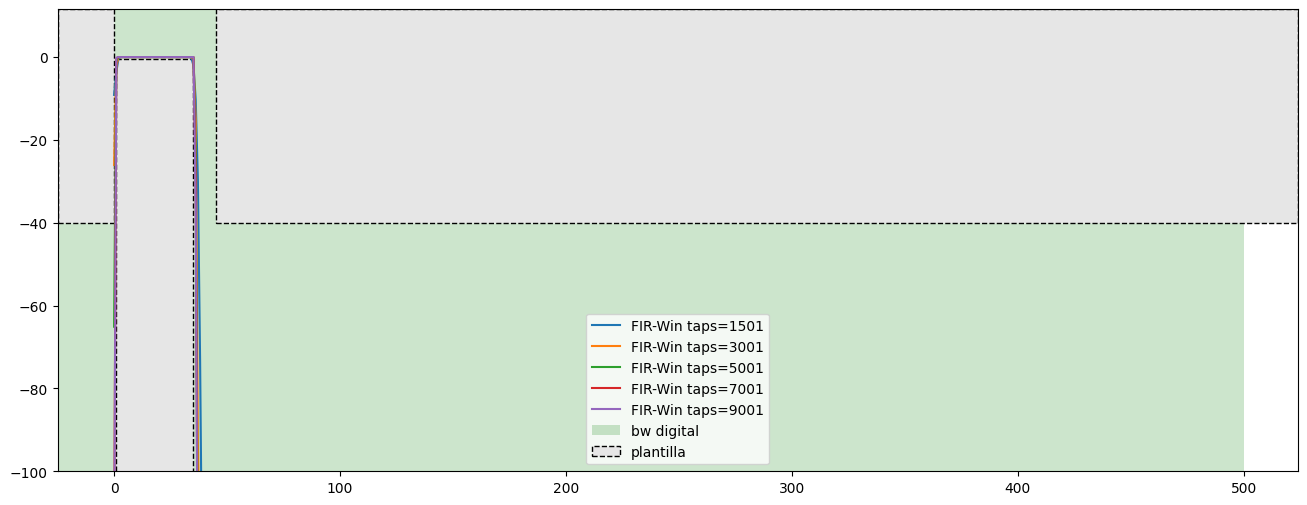

C:\Users\Usuario\AppData\Local\Temp\ipykernel_26092\4160740408.py:110: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


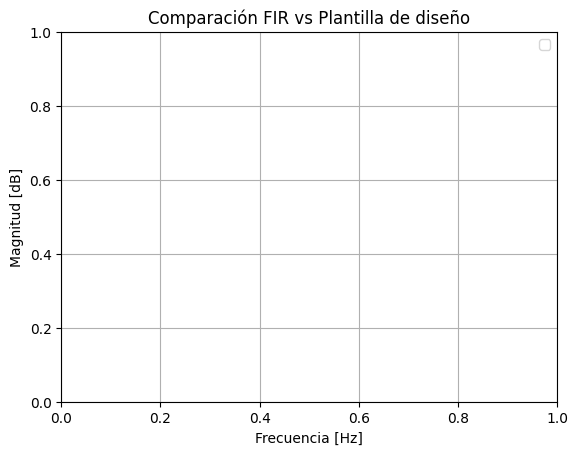

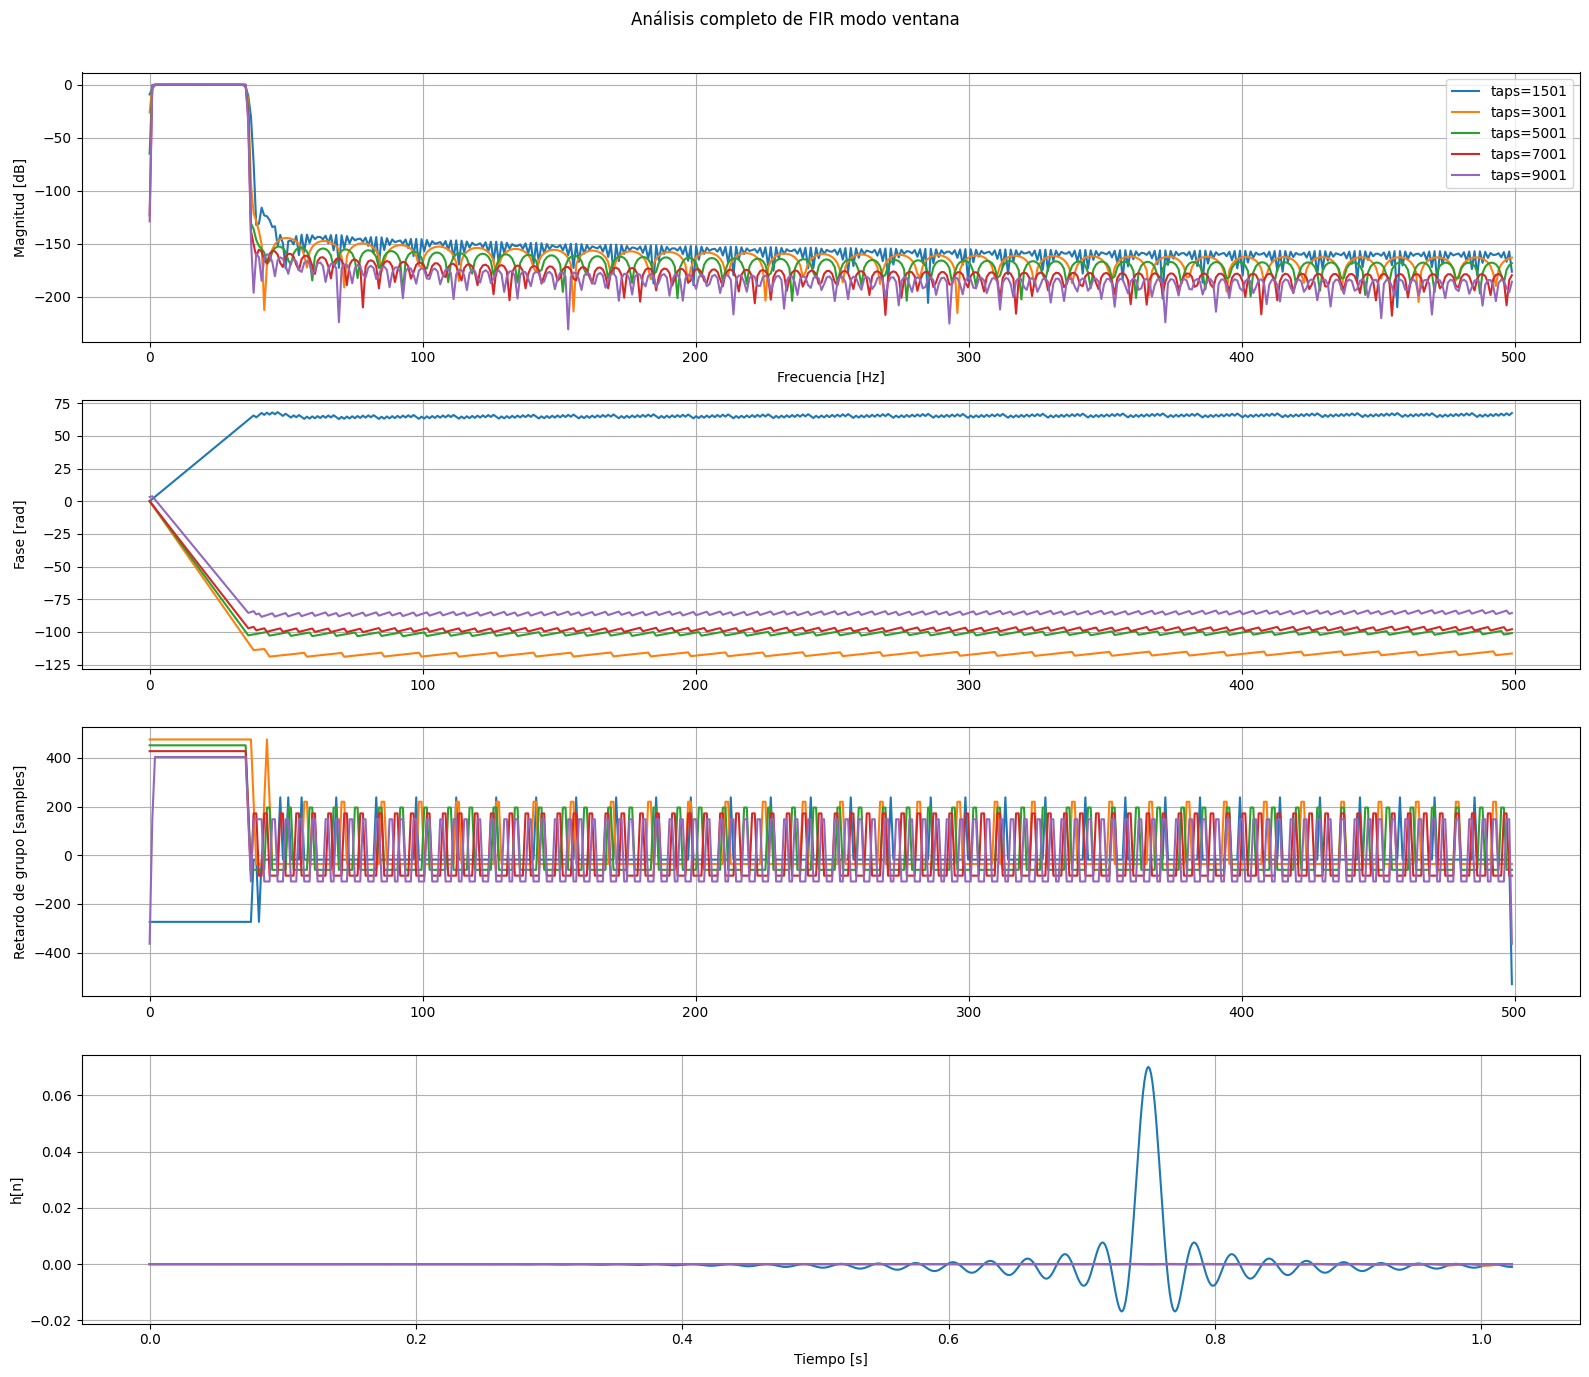

In [31]:
# Import common packages
from IPython.display import display, Markdown
import numpy as np
import scipy.signal as sig
import scipy.io as sio
from pytc2.sistemas_lineales import plot_plantilla
import matplotlib.pyplot as plt

# Carga del ECG
display(sio.whosmat("ecg.mat"))
mat_struct = sio.loadmat("ecg.mat")
ecg_one_lead = mat_struct["ecg_lead"].flatten()

# Parametros del filtro
ripple_db = 0.5  # Ripple en dB
atten_db = 40    # Atenuacion en dB

# Plantilla BandStop
fs1 = 0.1  # Hz
fp1 = 1    # Hz
fp2 = 35   # Hz
fs2 = 45   # Hz

# Parametros del sistema
fs = 1000  # Hz
nyq = fs / 2

#---------------------------------------------------------------------
def mag_phase_delay_impulseresp(
    b,
    a,
    sos=None,
    fs=2,
    worN=512,
    n_imp=1024,
    gd_units="samples",
):
    """
    Calcula magnitud, fase, retardo de grupo e impulso para FIR/IIR.
    Devuelve un diccionario con los resultados numéricos.
    """

    if sos is not None:
        w, h = sig.sosfreqz(sos, worN=worN, fs=fs)
    else:
        w, h = sig.freqz(b, a, worN=worN, fs=fs)

    abs_h = np.abs(h)
    abs_h[abs_h == 0] = 1e-20
    mag_db = 20 * np.log10(abs_h)

    phase_wrapped = np.angle(h)
    phase_unwrapped = np.unwrap(phase_wrapped)

    omega = 2 * np.pi * w
    gd_seconds = -np.gradient(phase_unwrapped, omega, edge_order=2)
    gd = gd_seconds * fs if gd_units == "samples" else gd_seconds

    impulse = np.zeros(n_imp)
    impulse[0] = 1.0
    imp_resp = sig.lfilter(b, a, impulse)

    t = np.arange(n_imp) / fs if fs else np.arange(n_imp)

    return {
        "w": w,
        "h": h,
        "mag_db": mag_db,
        "phase_wrapped": phase_wrapped,
        "phase_unwrapped": phase_unwrapped,
        "group_delay": gd,
        "t": t,
        "imp_resp": imp_resp,
    }

#----------------------------------------------------------------------

# Filtros FIR modo Ventana
taps_list = [1501, 3001, 5001, 7001, 9001]


#----------------------------------------------------------------------

# 2. Comparación de los filtros FIR con la plantilla
plt.figure(figsize=(16, 6))
for taps in taps_list:
    b = sig.firwin2(
        taps,
        freq=(0, fs1 + 0.5, fp1 - 0.2, fp2 + 0.5, fp2 + 1, nyq),
        gain=(0, 0, 1, 1, 0, 0),
        window="blackmanharris",
        fs=fs,
    )
    a = 1.0
    results = mag_phase_delay_impulseresp(b, a, fs=fs)
    plt.plot(results["w"], results["mag_db"], label=f"FIR-Win taps={taps}")

plot_plantilla(
    filter_type="bandpass",
    fpass=(fp1, fp2),
    fstop=(fs1, fs2),
    ripple=ripple_db,
    attenuation=atten_db,
    fs=fs,
)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.title("Comparación FIR vs Plantilla de diseño")
plt.grid(True)
plt.legend()
plt.show()

#----------------------------------------------------------------------

# 3. Análisis completo: magnitud, fase, retardo de grupo y respuesta al impulso
plt.figure(figsize=(16, 14))
for taps in taps_list:
    b = sig.firwin2(
        taps,
        freq=(0, fs1 + 0.5, fp1 - 0.2, fp2 + 0.5, fp2 + 1, nyq),
        gain=(0, 0, 1, 1, 0, 0),
        window="blackmanharris",
        fs=fs,
    )
    a = 1.0
    results = mag_phase_delay_impulseresp(b, a, fs=fs)

    # Magnitud
    plt.subplot(4, 1, 1)
    plt.plot(results["w"], results["mag_db"], label=f"taps={taps}")
    plt.ylabel("Magnitud [dB]")
    plt.xlabel("Frecuencia [Hz]")
    plt.grid(True)
    plt.legend()

    # Fase
    plt.subplot(4, 1, 2)
    plt.plot(results["w"], results["phase_unwrapped"], label=f"taps={taps}")
    plt.ylabel("Fase [rad]")
    plt.grid(True)

    # Retardo de grupo
    plt.subplot(4, 1, 3)
    plt.plot(results["w"], results["group_delay"], label=f"taps={taps}")
    plt.ylabel("Retardo de grupo [samples]")
    plt.grid(True)

    # Respuesta al impulso
    plt.subplot(4, 1, 4)
    plt.plot(results["t"], results["imp_resp"], label=f"taps={taps}")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("h[n]")
    plt.grid(True)

plt.suptitle("Análisis completo de FIR modo ventana")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


[('ecg_lead', (1129116, 1), 'double'),
 ('qrs_pattern1', (113, 1), 'double'),
 ('heartbeat_pattern1', (411, 1), 'double'),
 ('heartbeat_pattern2', (441, 1), 'double'),
 ('qrs_detections', (1903, 1), 'double')]

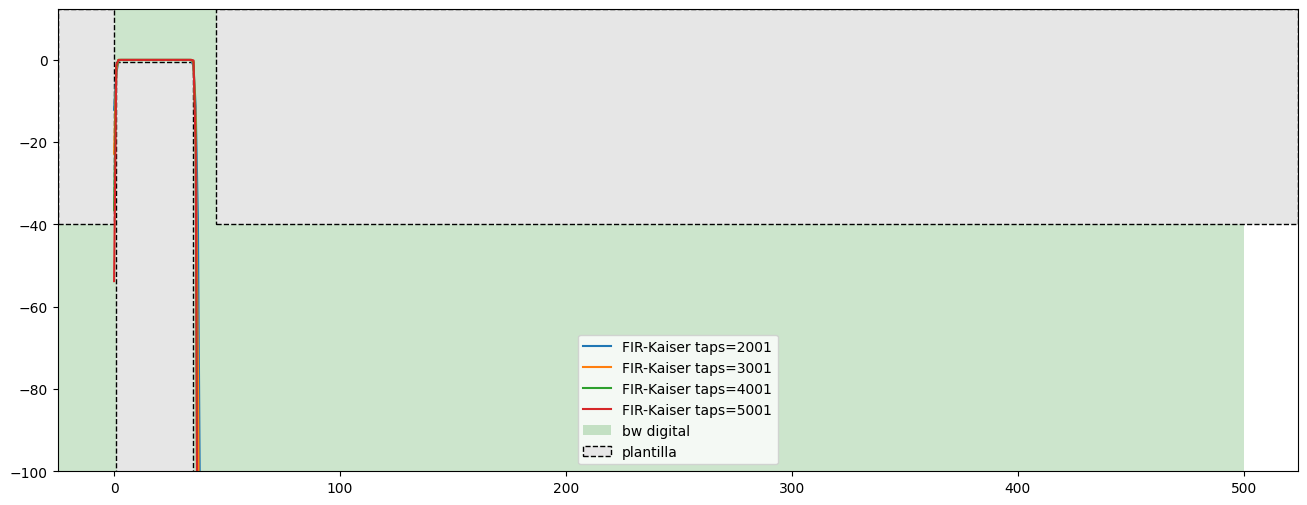

C:\Users\Usuario\AppData\Local\Temp\ipykernel_26092\355666550.py:113: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


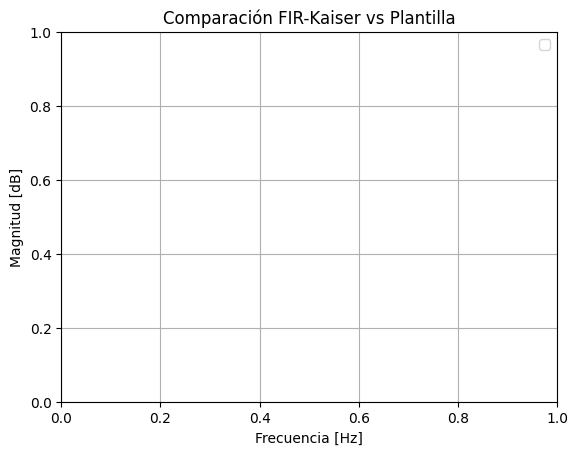

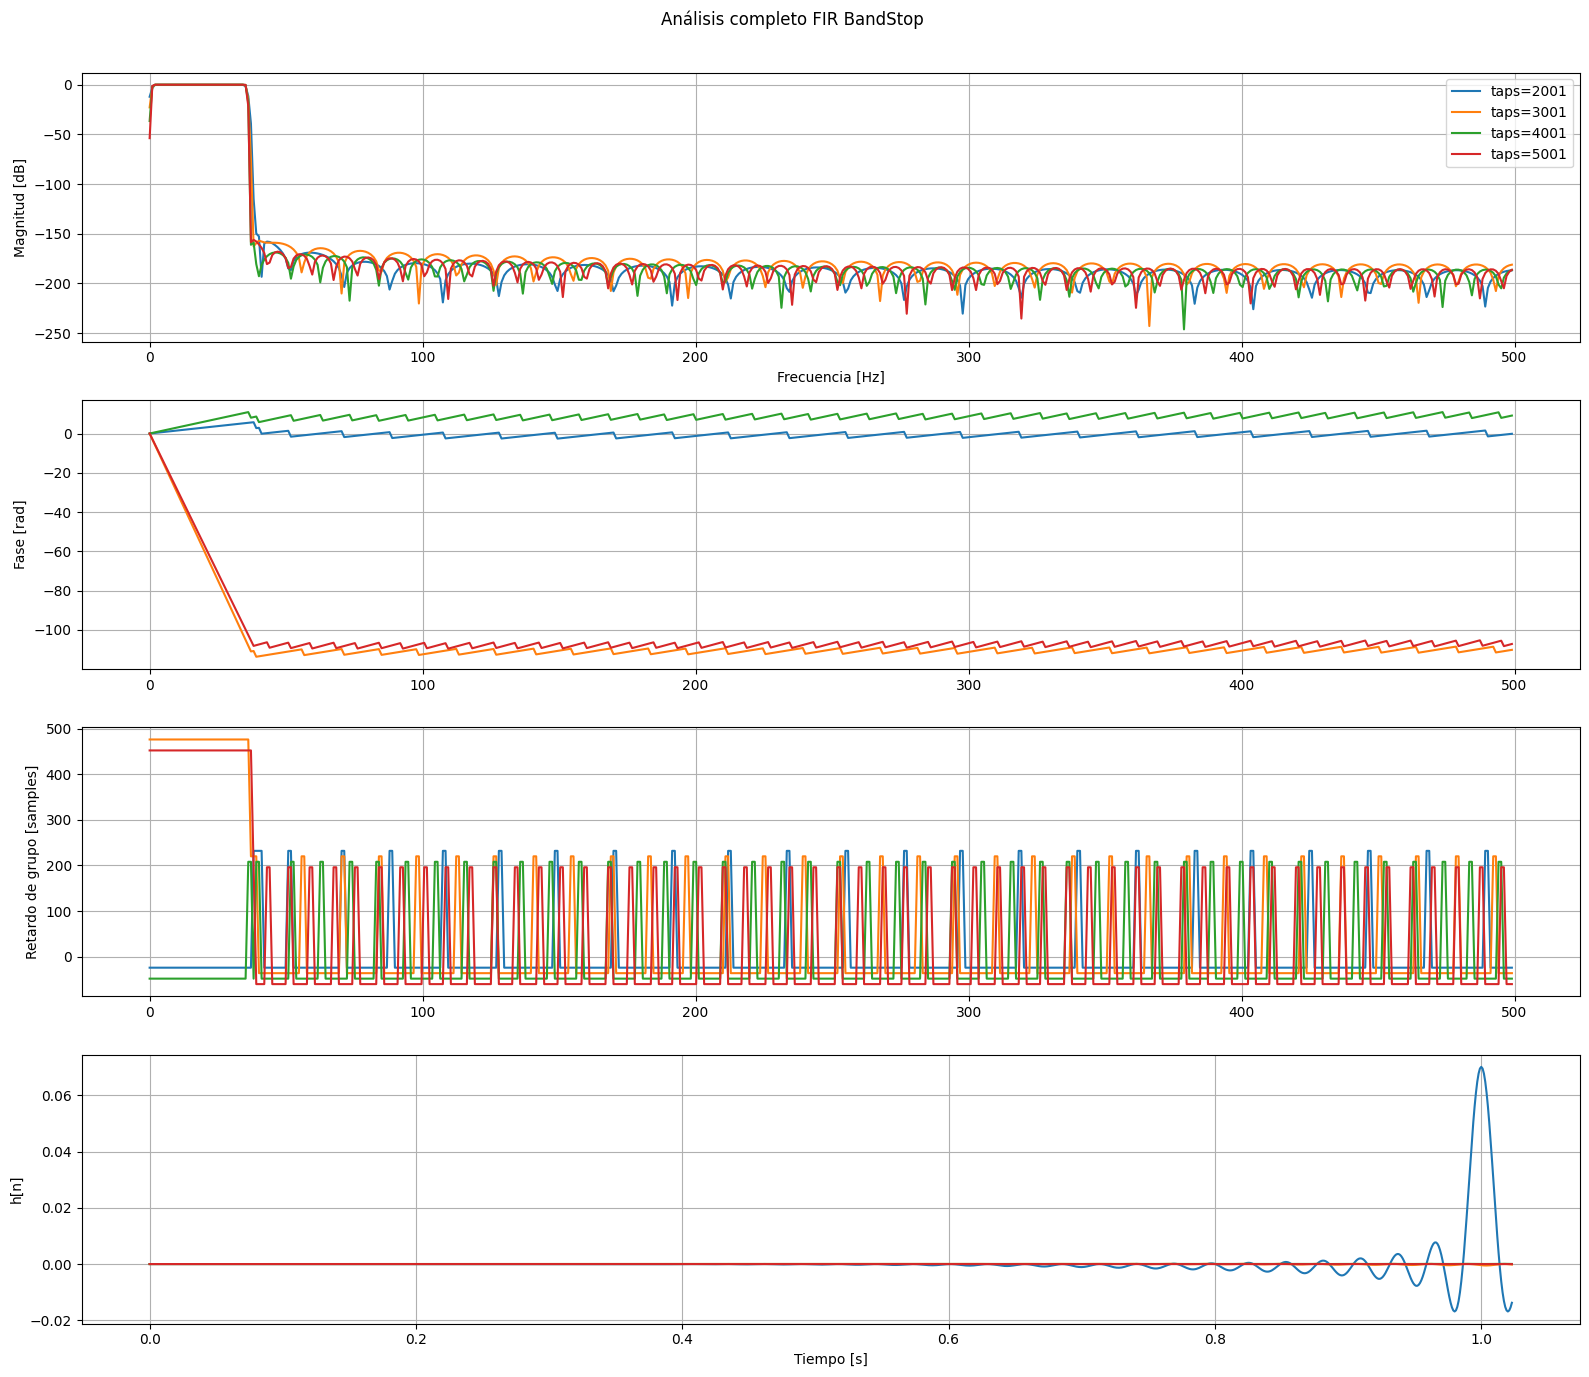

In [32]:
# Import common packages
from IPython.display import display, Markdown
import numpy as np
import scipy.signal as sig
import scipy.io as sio
from pytc2.sistemas_lineales import plot_plantilla
import matplotlib.pyplot as plt

# Carga del ECG
display(sio.whosmat("ecg.mat"))
mat_struct = sio.loadmat("ecg.mat")
ecg_one_lead = mat_struct["ecg_lead"].flatten()

# Parametros del filtro
ripple_db = 0.5  # Ripple en dB
atten_db = 40    # Atenuacion en dB

# Plantilla BandStop
fs1 = 0.1  # Hz
fp1 = 1    # Hz
fp2 = 35   # Hz
fs2 = 45   # Hz

# Parametros del sistema
fs = 1000  # Hz
nyq = fs / 2

#---------------------------------------------------------------------
def mag_phase_delay_impulseresp(
    b,
    a,
    sos=None,
    fs=2,
    worN=512,
    n_imp=1024,
    gd_units="samples",
):
    """
    Calcula magnitud, fase, retardo de grupo e impulso para FIR/IIR.
    Devuelve un diccionario con los resultados numéricos.
    """

    if sos is not None:
        w, h = sig.sosfreqz(sos, worN=worN, fs=fs)
    else:
        w, h = sig.freqz(b, a, worN=worN, fs=fs)

    abs_h = np.abs(h)
    abs_h[abs_h == 0] = 1e-20
    mag_db = 20 * np.log10(abs_h)

    phase_wrapped = np.angle(h)
    phase_unwrapped = np.unwrap(phase_wrapped)

    omega = 2 * np.pi * w
    gd_seconds = -np.gradient(phase_unwrapped, omega, edge_order=2)
    gd = gd_seconds * fs if gd_units == "samples" else gd_seconds

    impulse = np.zeros(n_imp)
    impulse[0] = 1.0
    imp_resp = sig.lfilter(b, a, impulse)

    t = np.arange(n_imp) / fs if fs else np.arange(n_imp)

    return {
        "w": w,
        "h": h,
        "mag_db": mag_db,
        "phase_wrapped": phase_wrapped,
        "phase_unwrapped": phase_unwrapped,
        "group_delay": gd,
        "t": t,
        "imp_resp": imp_resp,
    }

#----------------------------------------------------------------------

# Filtros FIR con ventana Kaiser
taps_list = [2001, 3001, 4001, 5001]
best_taps = 5001
b_firwin2 = []



#----------------------------------------------------------------------

# 2. Comparación FIR vs plantilla
plt.figure(figsize=(16, 6))
for taps in taps_list:
    b = sig.firwin2(
        taps,
        freq=(0, fs1 + 0.5, fp1 - 0.2, fp2 + 0.5, fp2 + 1, nyq),
        gain=(0, 0, 1, 1, 0, 0),
        window=("kaiser", 14),
        fs=fs,
    )
    a = 1.0
    results = mag_phase_delay_impulseresp(b, a, fs=fs)
    plt.plot(results["w"], results["mag_db"], label=f"FIR-Kaiser taps={taps}")

plot_plantilla(
    filter_type="bandpass",
    fpass=(fp1, fp2),
    fstop=(fs1, fs2),
    ripple=ripple_db,
    attenuation=atten_db,
    fs=fs,
)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.title("Comparación FIR-Kaiser vs Plantilla")
plt.grid(True)
plt.legend()
plt.show()

#----------------------------------------------------------------------

# 3. Análisis completo: magnitud, fase, retardo de grupo y respuesta al impulso
plt.figure(figsize=(16, 14))
for taps in taps_list:
    b = sig.firwin2(
        taps,
        freq=(0, fs1 + 0.5, fp1 - 0.2, fp2 + 0.5, fp2 + 1, nyq),
        gain=(0, 0, 1, 1, 0, 0),
        window=("kaiser", 14),
        fs=fs,
    )
    a = 1.0
    results = mag_phase_delay_impulseresp(b, a, fs=fs)

    # Magnitud
    plt.subplot(4, 1, 1)
    plt.plot(results["w"], results["mag_db"], label=f"taps={taps}")
    plt.ylabel("Magnitud [dB]")
    plt.xlabel("Frecuencia [Hz]")
    plt.grid(True)
    plt.legend()

    # Fase
    plt.subplot(4, 1, 2)
    plt.plot(results["w"], results["phase_unwrapped"], label=f"taps={taps}")
    plt.ylabel("Fase [rad]")
    plt.grid(True)

    # Retardo de grupo
    plt.subplot(4, 1, 3)
    plt.plot(results["w"], results["group_delay"], label=f"taps={taps}")
    plt.ylabel("Retardo de grupo [samples]")
    plt.grid(True)

    # Respuesta al impulso
    plt.subplot(4, 1, 4)
    plt.plot(results["t"], results["imp_resp"], label=f"taps={taps}")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("h[n]")
    plt.grid(True)

plt.suptitle("Análisis completo FIR BandStop ")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


[('ecg_lead', (1129116, 1), 'double'),
 ('qrs_pattern1', (113, 1), 'double'),
 ('heartbeat_pattern1', (411, 1), 'double'),
 ('heartbeat_pattern2', (441, 1), 'double'),
 ('qrs_detections', (1903, 1), 'double')]

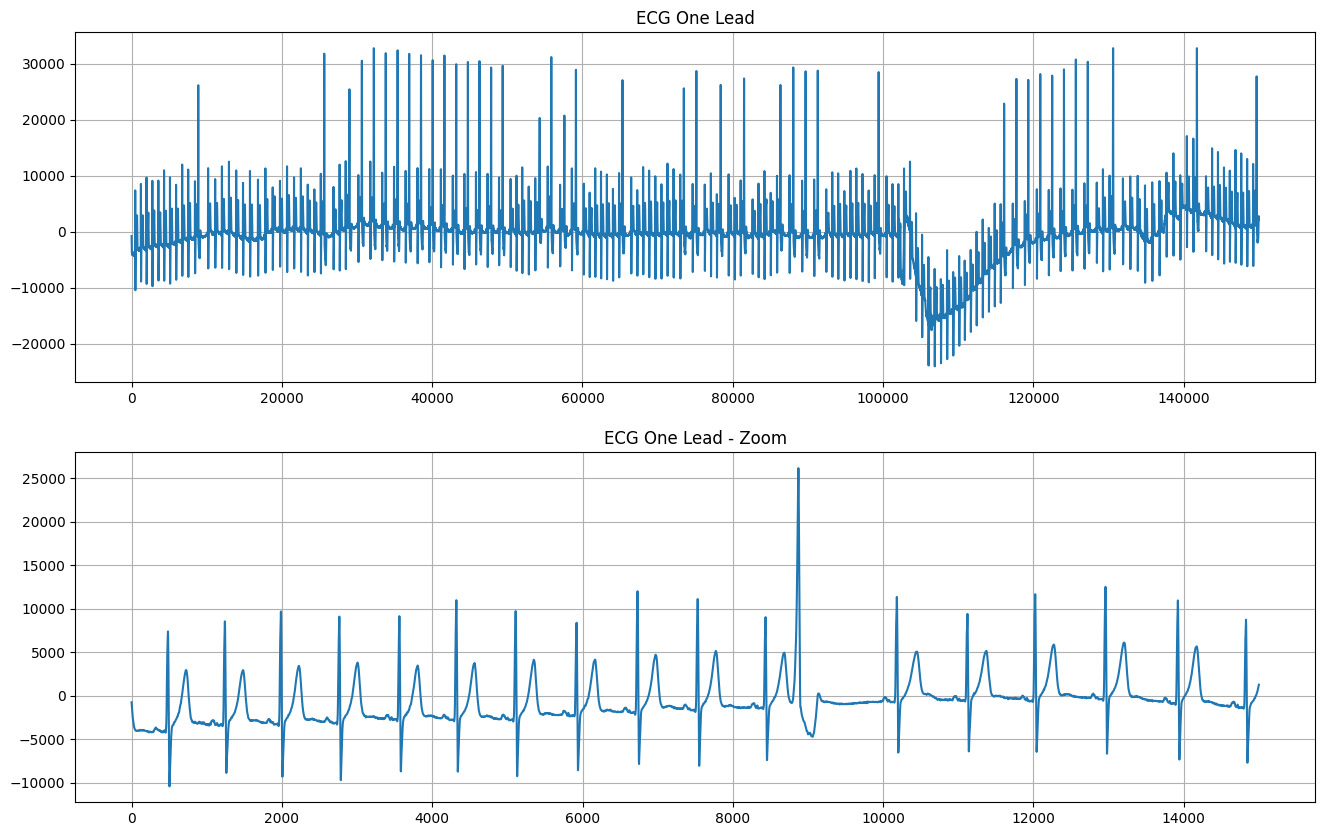

In [33]:

# Import common packages
from IPython.display import display, Markdown
import numpy as np
import scipy.signal as sig
import scipy.io as sio
from pytc2.sistemas_lineales import plot_plantilla

import matplotlib.pyplot as plt

display(sio.whosmat("ecg.mat"))
mat_struct = sio.loadmat("ecg.mat")

ecg_one_lead = mat_struct["ecg_lead"].flatten()

# Parametros del filtro
ripple_db = 0.5  # Ripple en dB
atten_db = 40  # Atenuacion en dB

# Plantilla BandStop
fs1 = 0.1  # Hz
fp1 = 1  # Hz
fp2 = 35  # Hz
fs2 = 45  # Hz

# Parametros del sistema
fs = 1000  # Hz
nyq = fs / 2

#---------------------------------------------------------------------

def mag_phase_delay_impulseresp(
    b,
    a,
    sos,
    fs=2,
    worN=512,
    n_imp=1024,
    gd_units="samples",
    max_display_s=0.1,
):
    """
    Calcula magnitud, fase, retardo de grupo e impulso,
    pero NO genera gráficos.
    Devuelve un diccionario con los resultados numéricos.
    """

    # --- frecuencia y respuesta en frecuencia
    if sos is not None:
        w, h = sig.sosfreqz(sos, worN=worN, fs=fs)
    else:
        w, h = sig.freqz(b, a, worN=worN, fs=fs)

    abs_h = np.abs(h)
    abs_h[abs_h == 0] = 1e-20
    mag_db = 20 * np.log10(abs_h)

    phase_wrapped = np.angle(h)
    phase_unwrapped = np.unwrap(phase_wrapped)

    # Retardo de grupo (en segundos)
    omega = 2 * np.pi * w
    gd_seconds = -np.gradient(phase_unwrapped, omega, edge_order=2)
    gd = gd_seconds * fs if gd_units == "samples" else gd_seconds

    # Respuesta al impulso
    impulse = np.zeros(n_imp, dtype=float)
    impulse[0] = 1.0
    if sos is not None:
        sos64 = np.asarray(sos, dtype=np.float64)
        imp_resp = sig.sosfilt(sos64, impulse)
    else:
        b64 = np.asarray(b, dtype=np.float64)
        a64 = np.asarray(a, dtype=np.float64)
        imp_resp = sig.lfilter(b64, a64, impulse)

    t = np.arange(n_imp) / fs if fs else np.arange(n_imp)

    return {
        "w": w,
        "h": h,
        "mag_db": mag_db,
        "phase_wrapped": phase_wrapped,
        "phase_unwrapped": phase_unwrapped,
        "group_delay": gd,
        "t": t,
        "imp_resp": imp_resp,
    }


#----------------------------------------------------------------------


# Plot de las señales ECG One Lead

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

ecg_one_lead_broad = ecg_one_lead[:150000]

axes[0].plot(ecg_one_lead_broad)
axes[0].set_title("ECG One Lead")
axes[0].grid()

ecg_one_lead_zoom = ecg_one_lead[:15000]

axes[1].plot(ecg_one_lead_zoom)
axes[1].set_title("ECG One Lead - Zoom")
axes[1].grid()

plt.show()

[('ecg_lead', (1129116, 1), 'double'),
 ('qrs_pattern1', (113, 1), 'double'),
 ('heartbeat_pattern1', (411, 1), 'double'),
 ('heartbeat_pattern2', (441, 1), 'double'),
 ('qrs_detections', (1903, 1), 'double')]

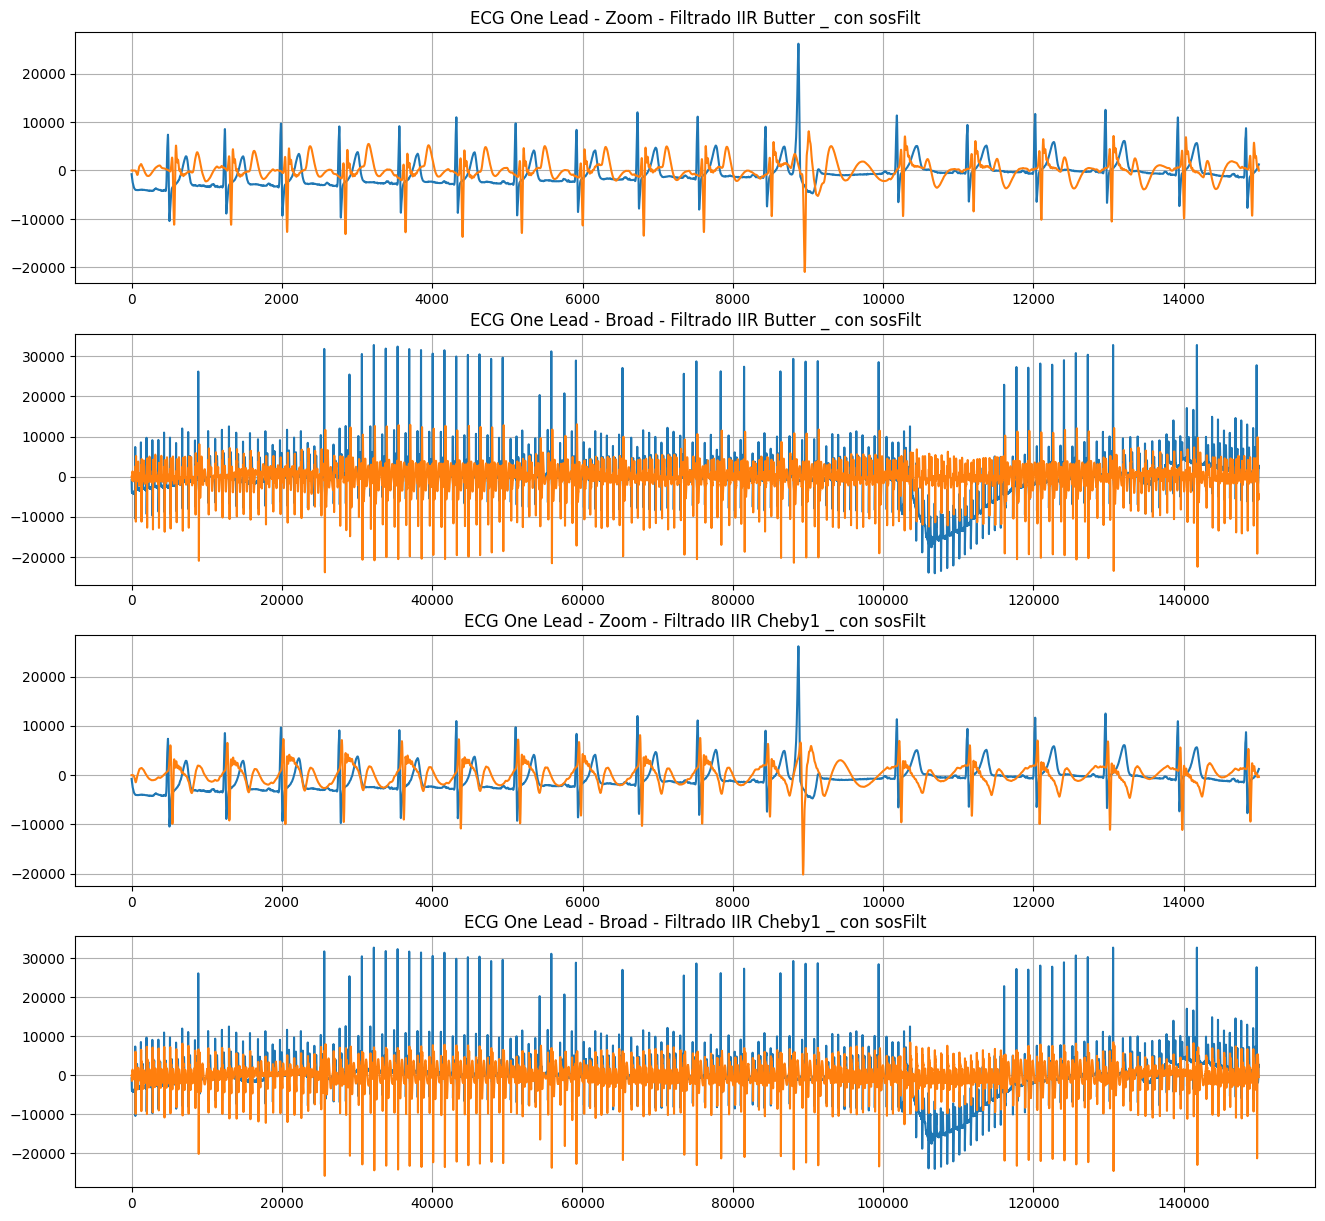

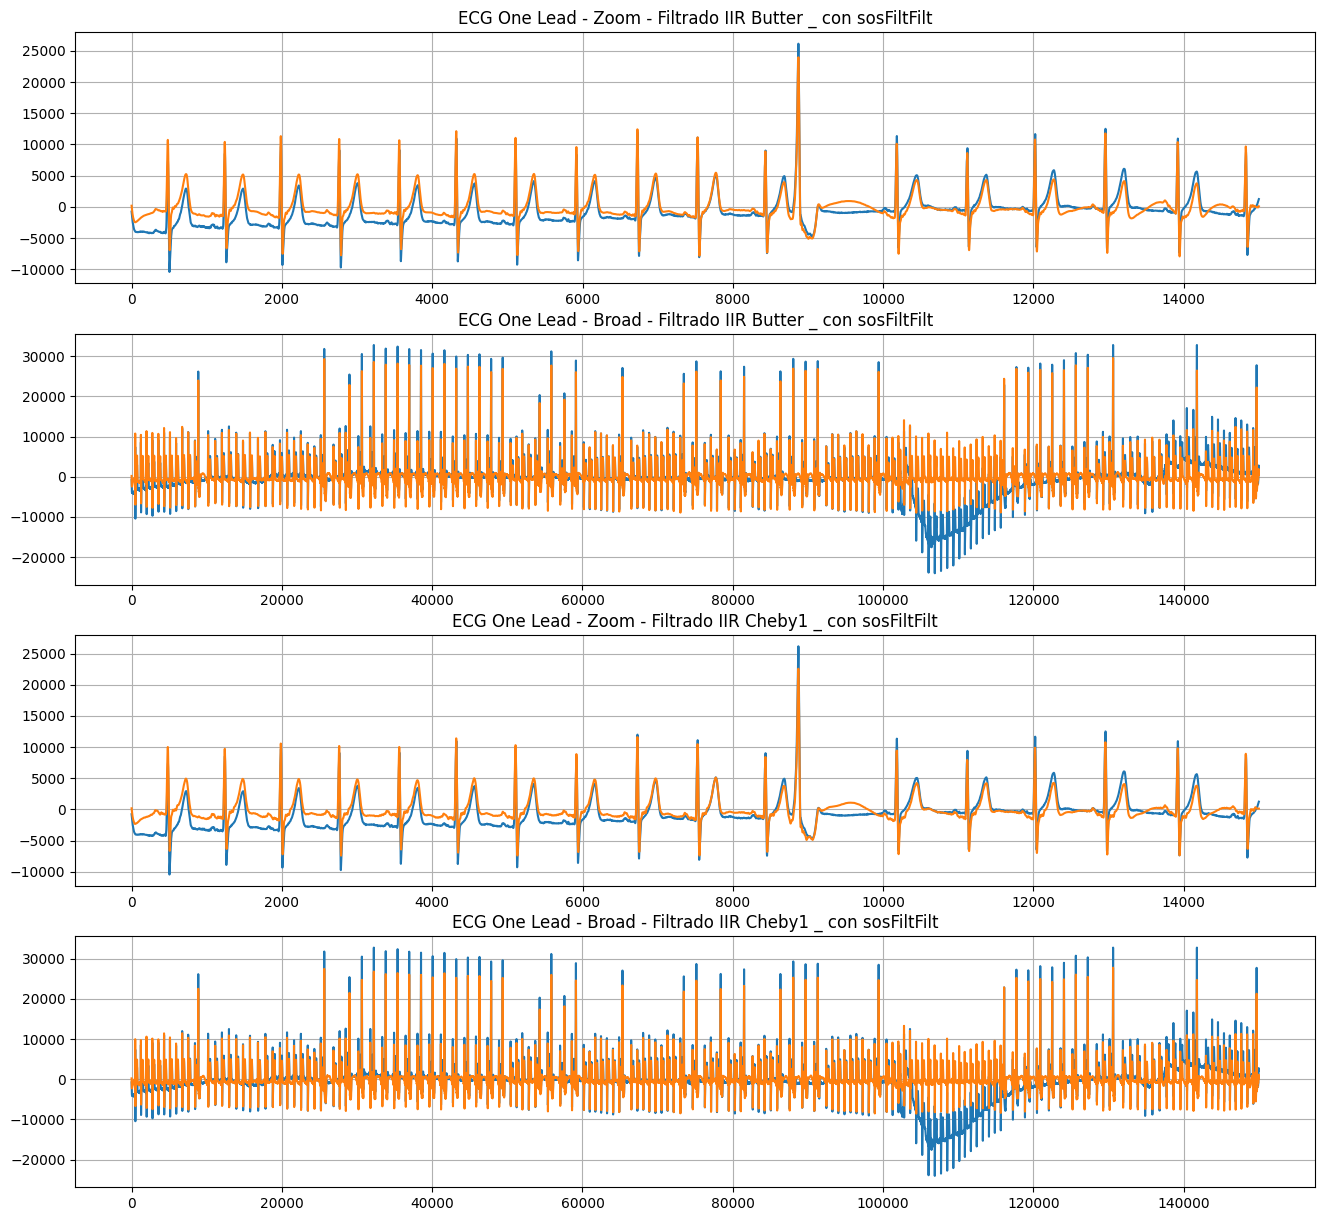

In [34]:

# Import common packages
from IPython.display import display, Markdown
import numpy as np
import scipy.signal as sig
import scipy.io as sio
from pytc2.sistemas_lineales import plot_plantilla

import matplotlib.pyplot as plt

display(sio.whosmat("ecg.mat"))
mat_struct = sio.loadmat("ecg.mat")

ecg_one_lead = mat_struct["ecg_lead"].flatten()

# Parametros del filtro
ripple_db = 0.5  # Ripple en dB
atten_db = 40  # Atenuacion en dB

# Plantilla BandStop
fs1 = 0.1  # Hz
fp1 = 1  # Hz
fp2 = 35  # Hz
fs2 = 45  # Hz

# Parametros del sistema
fs = 1000  # Hz
nyq = fs / 2

#---------------------------------------------------------------------

def mag_phase_delay_impulseresp(
    b,
    a,
    sos,
    fs=2,
    worN=512,
    n_imp=1024,
    gd_units="samples",
    max_display_s=0.1,
):
    """
    Calcula magnitud, fase, retardo de grupo e impulso,
    pero NO genera gráficos.
    Devuelve un diccionario con los resultados numéricos.
    """

    # --- frecuencia y respuesta en frecuencia
    if sos is not None:
        w, h = sig.sosfreqz(sos, worN=worN, fs=fs)
    else:
        w, h = sig.freqz(b, a, worN=worN, fs=fs)

    abs_h = np.abs(h)
    abs_h[abs_h == 0] = 1e-20
    mag_db = 20 * np.log10(abs_h)

    phase_wrapped = np.angle(h)
    phase_unwrapped = np.unwrap(phase_wrapped)

    # Retardo de grupo (en segundos)
    omega = 2 * np.pi * w
    gd_seconds = -np.gradient(phase_unwrapped, omega, edge_order=2)
    gd = gd_seconds * fs if gd_units == "samples" else gd_seconds

    # Respuesta al impulso
    impulse = np.zeros(n_imp, dtype=float)
    impulse[0] = 1.0
    if sos is not None:
        sos64 = np.asarray(sos, dtype=np.float64)
        imp_resp = sig.sosfilt(sos64, impulse)
    else:
        b64 = np.asarray(b, dtype=np.float64)
        a64 = np.asarray(a, dtype=np.float64)
        imp_resp = sig.lfilter(b64, a64, impulse)

    t = np.arange(n_imp) / fs if fs else np.arange(n_imp)

    return {
        "w": w,
        "h": h,
        "mag_db": mag_db,
        "phase_wrapped": phase_wrapped,
        "phase_unwrapped": phase_unwrapped,
        "group_delay": gd,
        "t": t,
        "imp_resp": imp_resp,
    }


#----------------------------------------------------------------------

# Filtro IIR
approx_funcs = ["butter", "cheby1", "cheby2", "ellip"]

# BandStop
wp = np.array([fp1, fp2])
ws = np.array([fs1, fs2])

# Guardo filtros para luego usar sosfilt y filtrar el ECG
# Se analiza el gráfico de la plantilla de manera visual
sos_iir_butter = []
sos_iir_cheby1 = []

for approx_func in approx_funcs:
    sos_iir = sig.iirdesign(
        wp=wp,
        ws=ws,
        gpass=ripple_db,
        gstop=atten_db,
        analog=False,
        ftype=approx_func,
        fs=fs,
        output="sos",
    )

    if approx_func == "butter":
        sos_iir_butter = sos_iir
    elif approx_func == "cheby1":
        sos_iir_cheby1 = sos_iir

    mag_phase_delay_impulseresp(
        None,
        None,
        sos=sos_iir,
        fs=fs,
        max_display_s=0.3,
    )

#-------------------------------------------------------------------

ecg_one_lead_broad = ecg_one_lead[:150000]
ecg_one_lead_zoom = ecg_one_lead[:15000]

#----------------------------------------------------------------------

# Filtrado de las señales ECG One Lead con sig.sosfilt()
# Hay distorsión de fase que debe solucionarse.

ecg_one_lead_zoom_filtered_by_iir_butter = sig.sosfilt(
    sos_iir_butter, ecg_one_lead_zoom
)
ecg_one_lead_broad_filtered_by_iir_butter = sig.sosfilt(
    sos_iir_butter, ecg_one_lead_broad
)

ecg_one_lead_zoom_filtered_by_iir_cheby1 = sig.sosfilt(
    sos_iir_cheby1, ecg_one_lead_zoom
)
ecg_one_lead_broad_filtered_by_iir_cheby1 = sig.sosfilt(
    sos_iir_cheby1, ecg_one_lead_broad
)


fig, axes = plt.subplots(4, 1, figsize=(16, 15))

# Plot Filtrado IIR Butter de ECG One Lead - Zoom
axes[0].plot(ecg_one_lead_zoom, label="ECG Zoom Original")
axes[0].plot(ecg_one_lead_zoom_filtered_by_iir_butter, label="Filtrado IIR Butter")
axes[0].set_title("ECG One Lead - Zoom - Filtrado IIR Butter _ con sosFilt")
axes[0].grid()

# Plot Filtrado IIR Butter de ECG One Lead - Broad
axes[1].plot(ecg_one_lead_broad, label="ECG Broad Original")
axes[1].plot(ecg_one_lead_broad_filtered_by_iir_butter, label="Filtrado IIR Butter")
axes[1].set_title("ECG One Lead - Broad - Filtrado IIR Butter _ con sosFilt")
axes[1].grid()

# Plot Filtrado IIR Cheby1 de ECG One Lead - Zoom
axes[2].plot(ecg_one_lead_zoom, label="ECG Zoom Original")
axes[2].plot(ecg_one_lead_zoom_filtered_by_iir_cheby1, label="Filtrado IIR Cheby1")
axes[2].set_title("ECG One Lead - Zoom - Filtrado IIR Cheby1 _ con sosFilt")
axes[2].grid()

# Plot Filtrado IIR Cheby1 de ECG One Lead - Broad
axes[3].plot(ecg_one_lead_broad, label="ECG Broad Original")
axes[3].plot(ecg_one_lead_broad_filtered_by_iir_cheby1, label="Filtrado IIR Cheby1")
axes[3].set_title("ECG One Lead - Broad - Filtrado IIR Cheby1 _ con sosFilt")
axes[3].grid()

#---------------------------------------------------------------------------------
# Con sig.sosfiltfilt() se soluciona internamente.
ecg_one_lead_zoom_filtered_by_iir_butter = sig.sosfiltfilt(
    sos_iir_butter, ecg_one_lead_zoom
)
ecg_one_lead_broad_filtered_by_iir_butter = sig.sosfiltfilt(
    sos_iir_butter, ecg_one_lead_broad
)

ecg_one_lead_zoom_filtered_by_iir_cheby1 = sig.sosfiltfilt(
    sos_iir_cheby1, ecg_one_lead_zoom
)
ecg_one_lead_broad_filtered_by_iir_cheby1 = sig.sosfiltfilt(
    sos_iir_cheby1, ecg_one_lead_broad
)

fig, axes = plt.subplots(4, 1, figsize=(16, 15))

# Plot Filtrado IIR Butter de ECG One Lead - Zoom
axes[0].plot(ecg_one_lead_zoom, label="ECG Zoom Original")
axes[0].plot(ecg_one_lead_zoom_filtered_by_iir_butter, label="Filtrado IIR Butter")
axes[0].set_title("ECG One Lead - Zoom - Filtrado IIR Butter _ con sosFiltFilt")
axes[0].grid()

# Plot Filtrado IIR Butter de ECG One Lead - Broad
axes[1].plot(ecg_one_lead_broad, label="ECG Broad Original")
axes[1].plot(ecg_one_lead_broad_filtered_by_iir_butter, label="Filtrado IIR Butter")
axes[1].set_title("ECG One Lead - Broad - Filtrado IIR Butter _ con sosFiltFilt")
axes[1].grid()

# Plot Filtrado IIR Cheby1 de ECG One Lead - Zoom
axes[2].plot(ecg_one_lead_zoom, label="ECG Zoom Original")
axes[2].plot(ecg_one_lead_zoom_filtered_by_iir_cheby1, label="Filtrado IIR Cheby1")
axes[2].set_title("ECG One Lead - Zoom - Filtrado IIR Cheby1 _ con sosFiltFilt")
axes[2].grid()

# Plot Filtrado IIR Cheby1 de ECG One Lead - Broad
axes[3].plot(ecg_one_lead_broad, label="ECG Broad Original")
axes[3].plot(ecg_one_lead_broad_filtered_by_iir_cheby1, label="Filtrado IIR Cheby1")
axes[3].set_title("ECG One Lead - Broad - Filtrado IIR Cheby1 _ con sosFiltFilt")
axes[3].grid()


[('ecg_lead', (1129116, 1), 'double'),
 ('qrs_pattern1', (113, 1), 'double'),
 ('heartbeat_pattern1', (411, 1), 'double'),
 ('heartbeat_pattern2', (441, 1), 'double'),
 ('qrs_detections', (1903, 1), 'double')]

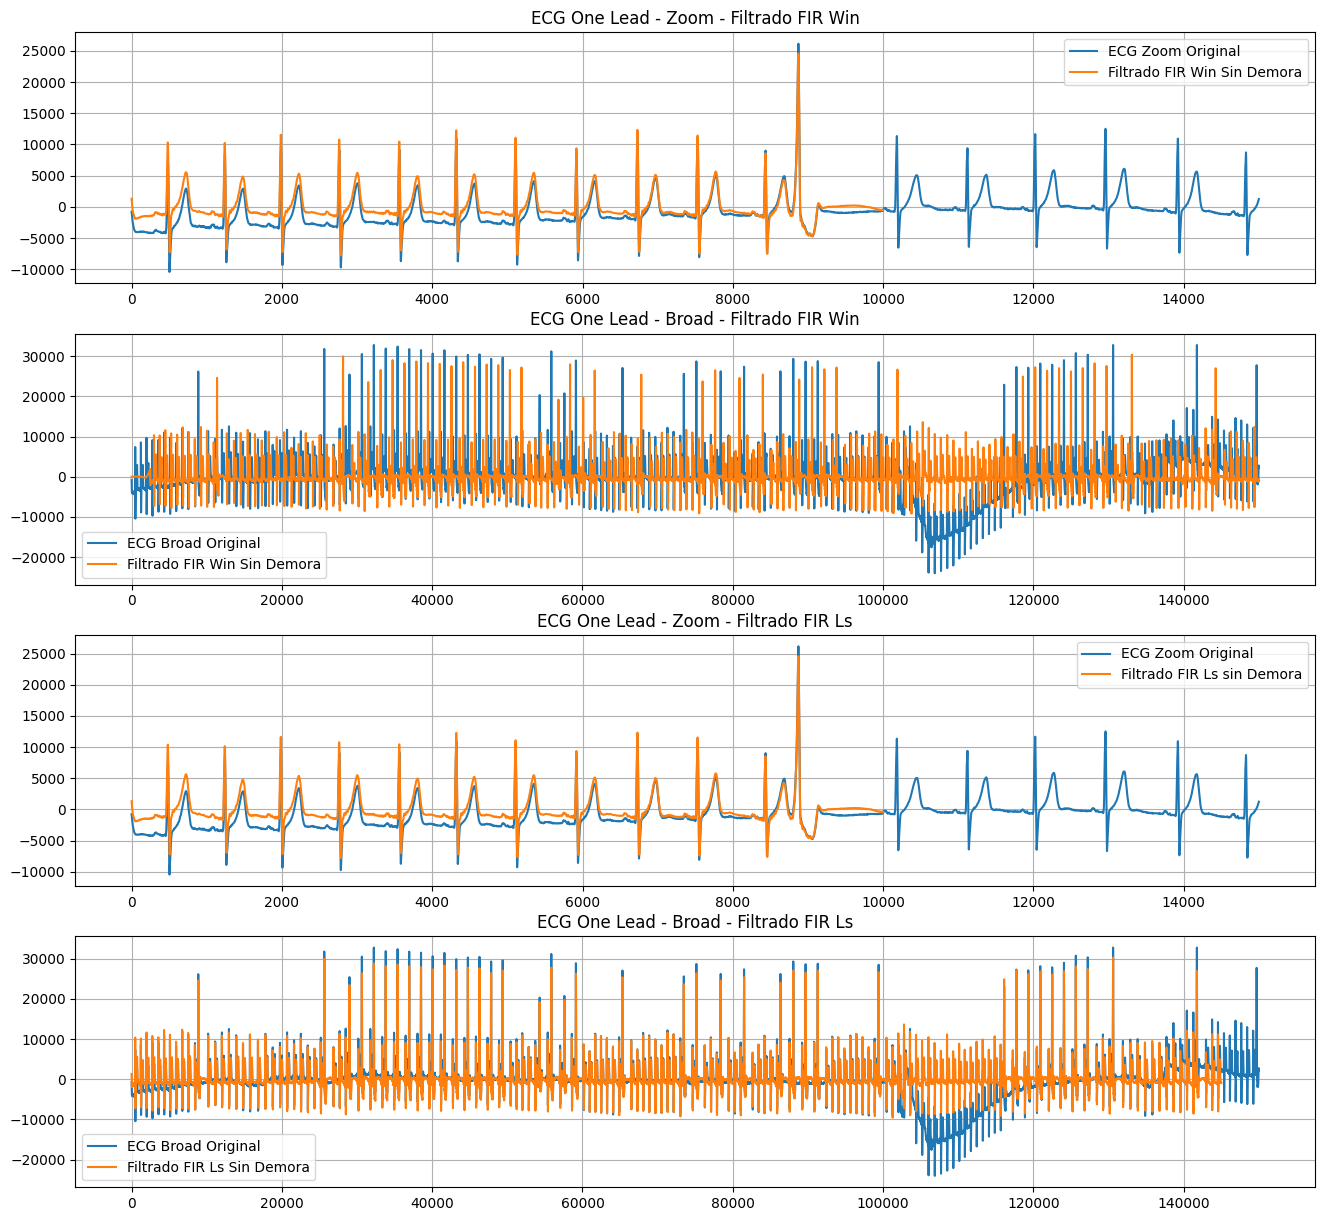

In [35]:

# Import common packages
from IPython.display import display, Markdown
import numpy as np
import scipy.signal as sig
import scipy.io as sio
from pytc2.sistemas_lineales import plot_plantilla

import matplotlib.pyplot as plt

display(sio.whosmat("ecg.mat"))
mat_struct = sio.loadmat("ecg.mat")

ecg_one_lead = mat_struct["ecg_lead"].flatten()

# Parametros del filtro
ripple_db = 0.5  # Ripple en dB
atten_db = 40  # Atenuacion en dB

# Plantilla BandStop
fs1 = 0.1  # Hz
fp1 = 1  # Hz
fp2 = 35  # Hz
fs2 = 45  # Hz

# Parametros del sistema
fs = 1000  # Hz
nyq = fs / 2

#---------------------------------------------------------------------

def mag_phase_delay_impulseresp(
    b,
    a,
    sos,
    fs=2,
    worN=512,
    n_imp=1024,
    gd_units="samples",
    max_display_s=0.1,
):
    """
    Calcula magnitud, fase, retardo de grupo e impulso,
    pero NO genera gráficos.
    Devuelve un diccionario con los resultados numéricos.
    """

    # --- frecuencia y respuesta en frecuencia
    if sos is not None:
        w, h = sig.sosfreqz(sos, worN=worN, fs=fs)
    else:
        w, h = sig.freqz(b, a, worN=worN, fs=fs)

    abs_h = np.abs(h)
    abs_h[abs_h == 0] = 1e-20
    mag_db = 20 * np.log10(abs_h)

    phase_wrapped = np.angle(h)
    phase_unwrapped = np.unwrap(phase_wrapped)

    # Retardo de grupo (en segundos)
    omega = 2 * np.pi * w
    gd_seconds = -np.gradient(phase_unwrapped, omega, edge_order=2)
    gd = gd_seconds * fs if gd_units == "samples" else gd_seconds

    # Respuesta al impulso
    impulse = np.zeros(n_imp, dtype=float)
    impulse[0] = 1.0
    if sos is not None:
        sos64 = np.asarray(sos, dtype=np.float64)
        imp_resp = sig.sosfilt(sos64, impulse)
    else:
        b64 = np.asarray(b, dtype=np.float64)
        a64 = np.asarray(a, dtype=np.float64)
        imp_resp = sig.lfilter(b64, a64, impulse)

    t = np.arange(n_imp) / fs if fs else np.arange(n_imp)

    return {
        "w": w,
        "h": h,
        "mag_db": mag_db,
        "phase_wrapped": phase_wrapped,
        "phase_unwrapped": phase_unwrapped,
        "group_delay": gd,
        "t": t,
        "imp_resp": imp_resp,
    }


#----------------------------------------------------------------------

# Número de taps
num_taps = 5001  

# Diseño de FIR con firwin2 (pasabanda)
b_firwin2 = sig.firwin2(
    num_taps,
    [0, fs1 + 0.5, fp1 - 0.2, fp2 + 0.5, fp2 + 1, nyq],
    [0, 0, 1, 1, 0, 0],
    fs=fs,
)

# Diseño de FIR con firls (least-squares)
b_firls = sig.firls(
    num_taps,
    [0, fs1 + 0.5, fp1 - 0.2, fp2 + 0.5, fp2 + 1, nyq],
    [0, 0, 1, 1, 0, 0],
    fs=fs,
)

#------------------------------------------------------------------------

ecg_one_lead_broad = ecg_one_lead[:150000]
ecg_one_lead_zoom = ecg_one_lead[:15000]

#----------------------------------------------------------------------


ecg_one_lead_zoom_filtered_by_firwin2 = sig.lfilter(b_firwin2, [1], ecg_one_lead_zoom)
ecg_one_lead_broad_filtered_by_firwin2 = sig.lfilter(b_firwin2, [1], ecg_one_lead_broad)

ecg_one_lead_zoom_filtered_by_firls = sig.lfilter(b_firls, [1], ecg_one_lead_zoom)
ecg_one_lead_broad_filtered_by_firls = sig.lfilter(b_firls, [1], ecg_one_lead_broad)


fig, axes = plt.subplots(4, 1, figsize=(16, 15))

# Arreglar la demora del filtro FIR
demora = (5001 - 1) // 2

# Plot Filtrado FIR Win de ECG One Lead - Zoom
axes[0].plot(ecg_one_lead_zoom, label="ECG Zoom Original")
axes[0].plot(
    ecg_one_lead_zoom_filtered_by_firwin2[demora:-demora],
    label="Filtrado FIR Win Sin Demora",
)
# axes[0].plot(ecg_one_lead_zoom_filtered_by_firwin2, label="Filtrado FIR Win")
axes[0].set_title("ECG One Lead - Zoom - Filtrado FIR Win")
axes[0].grid()
axes[0].legend()

# Plot Filtrado FIR Win de ECG One Lead - Broad
axes[1].plot(ecg_one_lead_broad, label="ECG Broad Original")
axes[1].plot(
    ecg_one_lead_broad_filtered_by_firwin2, label="Filtrado FIR Win Sin Demora"
)
# axes[1].plot(
#     ecg_one_lead_broad_filtered_by_firwin2[demora:-demora], label="Filtrado FIR Win"
# )
axes[1].set_title("ECG One Lead - Broad - Filtrado FIR Win")
axes[1].grid()
axes[1].legend()

# Plot Filtrado FIR Ls de ECG One Lead - Zoom
axes[2].plot(ecg_one_lead_zoom, label="ECG Zoom Original")
axes[2].plot(
    ecg_one_lead_zoom_filtered_by_firls[demora:-demora],
    label="Filtrado FIR Ls sin Demora",
)
# axes[2].plot(ecg_one_lead_zoom_filtered_by_firls, label="Filtrado FIR Ls")
axes[2].set_title("ECG One Lead - Zoom - Filtrado FIR Ls")
axes[2].grid()
axes[2].legend()

# Plot Filtrado FIR Ls de ECG One Lead - Broad
axes[3].plot(ecg_one_lead_broad, label="ECG Broad Original")
axes[3].plot(
    ecg_one_lead_broad_filtered_by_firls[demora:-demora],
    label="Filtrado FIR Ls Sin Demora",
)
# axes[3].plot(ecg_one_lead_broad_filtered_by_firls, label="Filtrado FIR Ls")
axes[3].set_title("ECG One Lead - Broad - Filtrado FIR Ls")
axes[3].grid()
axes[3].legend()

plt.show()
